### Analysis of Sampling Results

In [18]:
# --- imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import gpflow

import bilby
from bilby.core.utils import random

import scipy.special
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# --- available results ---
emcee_small_results = bilby.result.read_in_result(f'sampler_testing/emcee_small_result.json')  
#pymc_small_results = bilby.result.read_in_result(f'sampler_testing/pymc_small_result.json')

# emcee_small_results.plot_walkers()
# pymc_small_results.plot_walkers()

In [3]:
# --- to load diabetes data ---
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
X = diabetes.data

selected_features = ['bmi', 'bp', 's1']
X = X[selected_features]

label_names = diabetes.feature_names
y = diabetes.target

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=22)

ytrain = ytrain.to_numpy().reshape(-1,1)
ytest = ytest.to_numpy().reshape(-1,1)

scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain) # fit and scale training data
Xtest = scaler.transform(Xtest) # scale test data

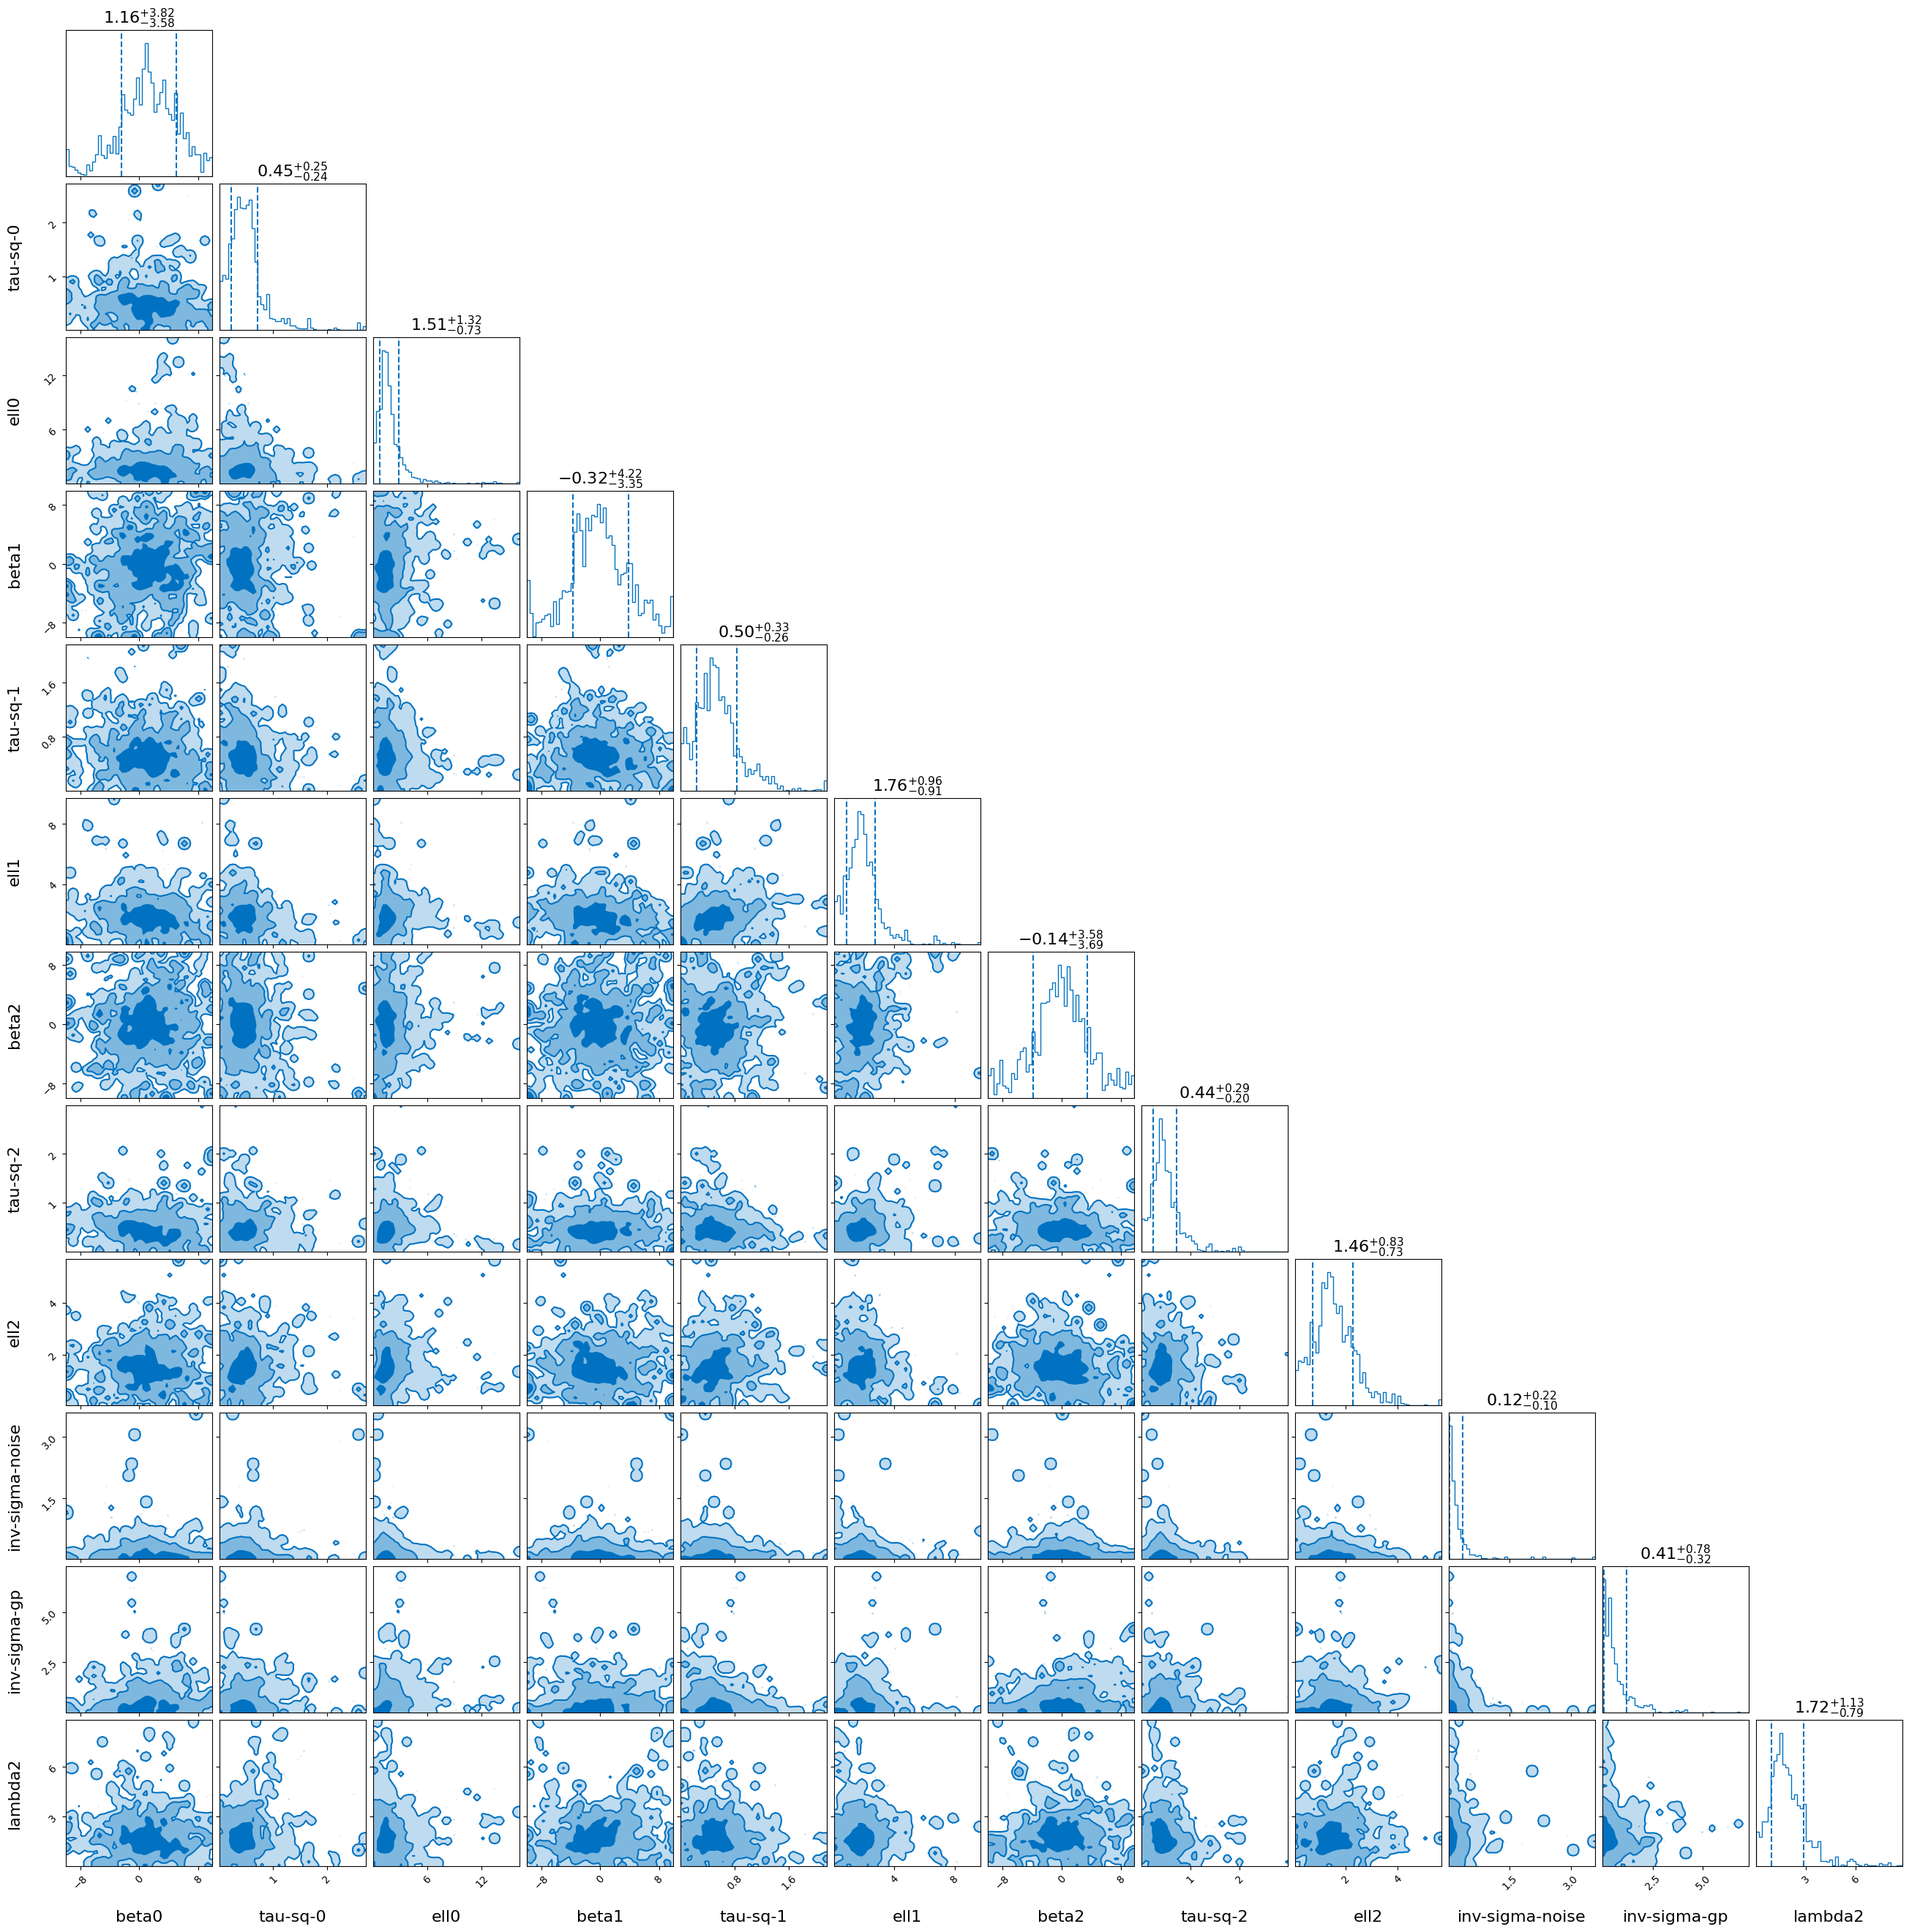

In [4]:
# --- corner plot ---
emcee_small_results.plot_corner()

In [5]:
# --- trace plot ---
emcee_small_results.plot_walkers()
# clearly has not converged in 50 iterations...

In [6]:
# --- use results to set parameters for gaussian process ---

# create a dictionary to store the median values of all sampled parameters
emcee_small_results.posterior
posterior_medians = {}
keys = emcee_small_results.posterior.keys()
for key in keys:
    posterior_medians[key] = np.median(emcee_small_results.posterior[key]).item()

In [7]:
posterior_medians

{'beta0': 1.1556547174341387,
 'tau_sq_0': 0.4539008056255492,
 'ell0': 1.5067960022406015,
 'beta1': -0.3196571341720147,
 'tau_sq_1': 0.5042031094979316,
 'ell1': 1.759363868595268,
 'beta2': -0.13551524620588262,
 'tau_sq_2': 0.43603999986574055,
 'ell2': 1.4583060534715957,
 'inv_sigma_noise': 0.11755050230955194,
 'inv_sigma_gp': 0.40966488780458865,
 'lambda2': 1.7184364216159764,
 'log_likelihood': -15863.12787735457,
 'log_prior': -17.340204606805145}

In [8]:
# sort out lengthscale params (ells)
lengthscales = []
betas = []

for i in range(X.shape[1]):
    lengthscales.append(posterior_medians[f'ell{i}'])
    betas.append(posterior_medians[f'beta{i}'])

sigma_noise = 1 / posterior_medians['inv_sigma_noise']
sigma_gp = 1 / posterior_medians['inv_sigma_gp']
    

In [9]:
# --- create gaussian process model with sampled parameters ---

# define kernel, mean function, and model
kernel = gpflow.kernels.SquaredExponential(
    lengthscales=lengthscales, 
    variance = sigma_gp**2) # set kernel with sampled lengthscales and variance

mean_fn = gpflow.mean_functions.Linear(
    A=np.diag(betas), 
    b=0.0) # set linear mean function

likelihood = gpflow.likelihoods.Gaussian(
    variance=sigma_noise**2)

# create model
mod = gpflow.models.GPR(
    data=(Xtrain, ytrain), 
    kernel=kernel, 
    mean_function=mean_fn,
    likelihood=likelihood)

In [17]:
# --- evaluate model's predictions ---

# training data
mu_train, var_train = mod.predict_f(Xtrain)
mu_train = mu_train.numpy().flatten()
var_train = var_train.numpy().flatten()

mse_train = np.mean((ytrain - mu_train)**2)
print(f"Training MSE: {mse_train}")

# test data
mu_test, var_test = mod.predict_f(Xtest)
mu_test = mu_test.numpy().flatten()
var_test = var_test.numpy().flatten()

mse_test = np.mean((ytest - mu_test)**2)
print(f"Test MSE: {mse_test}")


Training MSE: 7740.622937038169
Test MSE: 8226.151868241313


In [ ]:
ell_samples = np.array([result.posterior[f"ell{i}"] for i in range(X.shape[1])]).T
ell_medians = np.median(ell_samples, axis=0)
ell_lower = np.percentile(ell_samples, 2.5, axis=0)
ell_upper = np.percentile(ell_samples, 97.5, axis=0)
ell_table = pd.DataFrame({
    "Variable": [f"ell_{i+1}" for i in range(ell_samples.shape[1])],
    "Posterior Median": ell_medians,
    "95% Credible Interval": [f"({l:.2f}, {u:.2f})" for l, u in zip(ell_lower, ell_upper)]})


ell_table